<a href="https://colab.research.google.com/github/xMrTuffnut/ai-companion-wellbeing/blob/main/RQ1_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import pandas as pd                 #tables
import matplotlib.pyplot as plt     #graphs
import seaborn as sns               #graphs
from scipy import stats             #statistics

In [69]:
url = "https://raw.githubusercontent.com/xMrTuffnut/ai-companion-wellbeing/main/data/clean.csv" #clear data
df = pd.read_csv(url)     #read table and put it into df
df.shape                  #shows table

(1131, 17)

In [70]:
df.head()       #shows that everything readable

,participant_id,well_being,intensity,companionship_prim,companionship_desc,self_disclosure,social_network_scale,tenure_of_activity,donated,male,non_binary,age,single,age_group,gender,companion_group,tenure_group
0,P001,5.500000,-0.726215,0,0,-0.058645,0.641817,-1.821462,0,0,0,28,0,25-34,female,Other use,1
1,P002,1.833333,-1.437133,0,1,0.506863,-0.875530,-0.462575,1,0,0,36,1,35-44,female,Other use,2
2,P003,5.500000,0.529299,0,0,0.506863,1.147600,0.896313,0,0,0,48,0,45+,female,Other use,3
3,P004,4.500000,-0.637609,1,1,0.393761,-1.381312,-0.462575,0,1,0,53,0,45+,male,Companion (primary use),2
4,P005,3.333333,-0.738990,0,0,-0.511052,-0.875530,0.896313,0,1,0,28,1,25-34,male,Other use,3


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1131 entries, 0 to 1130
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   participant_id        1131 non-null   object 
 1   well_being            1131 non-null   float64
 2   intensity             1131 non-null   float64
 3   companionship_prim    1131 non-null   int64  
 4   companionship_desc    1131 non-null   int64  
 5   self_disclosure       1131 non-null   float64
 6   social_network_scale  1131 non-null   float64
 7   tenure_of_activity    1131 non-null   float64
 8   donated               1131 non-null   int64  
 9   male                  1131 non-null   int64  
 10  non_binary            1131 non-null   int64  
 11  age                   1131 non-null   int64  
 12  single                1131 non-null   int64  
 13  age_group             1131 non-null   object 
 14  gender                1131 non-null   object 
 15  companion_group      

In [72]:
print(df["well_being"].mean())
df.groupby("companion_group")["well_being"].mean()

4.7892720306595935


,well_being
companion_group,
Companion (primary use),4.439055
Other use,4.836342


In [73]:
df.groupby("companion_group")["well_being"].describe()    #H0 - no difference in means

,count,mean,std,min,25%,50%,75%,max
companion_group,,,,,,,,
Companion (primary use),134.0,4.439055,1.451174,1.0,3.333333,4.666667,5.666667,7.0
Other use,997.0,4.836342,1.305427,1.0,4.000000,5.000000,5.833333,7.0


In [74]:
companion = df[df["companionship_prim"] == 1]["well_being"]
others    = df[df["companionship_prim"] == 0]["well_being"]

print(len(companion), len(others))

134 997


In [75]:
stats.levene(companion, others)

LeveneResult(statistic=np.float64(5.56737608374894), pvalue=np.float64(0.01846764173595231))

Levene's test: W = 5.57, p = .018. The variances of the two groups are not equal, and the groups are very different in size (134 vs. 997). Therefore we use Welch's t-test, which does not assume equal variances.

In [76]:
stats.ttest_ind(companion, others, equal_var=False)     #test_ind - потому что группы независимые


TtestResult(statistic=np.float64(-3.0096691661550126), pvalue=np.float64(0.0030307058192594522), df=np.float64(163.24602057666843))

In [77]:
# 1. Разница средних
diff = companion.mean() - others.mean()
print("Разница средних:", round(diff, 2))

Разница средних: -0.4


In [78]:
# 2. Общий (объединённый, pooled) разброс двух групп
n1, n2 = len(companion), len(others)
sd_pooled = (((n1 - 1) * companion.var() + (n2 - 1) * others.var()) / (n1 + n2 - 2)) ** 0.5
print("Общее SD:", round(sd_pooled, 2))

Общее SD: 1.32


In [79]:
# 3. Cohen's d
d = diff / sd_pooled
print("Cohen's d:", round(d, 2))

Cohen's d: -0.3


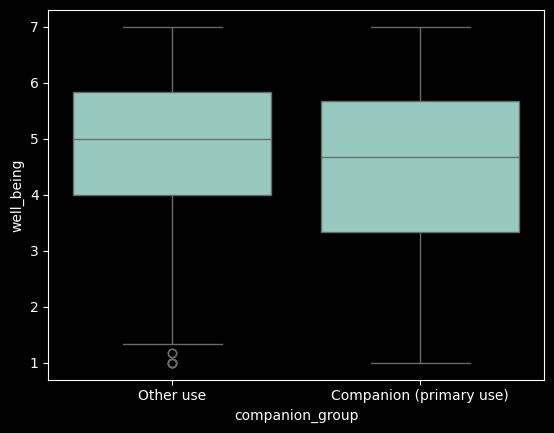

In [80]:
sns.boxplot(data=df, x="companion_group", y="well_being")
plt.show()

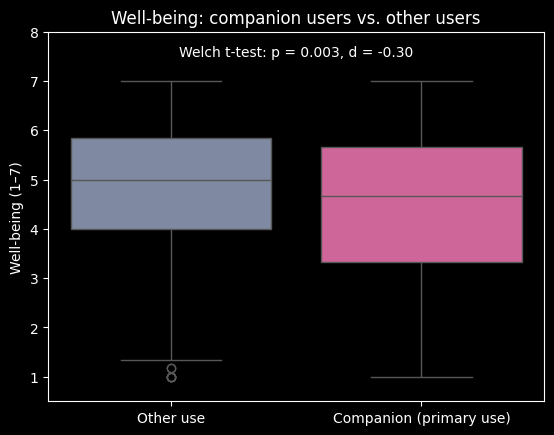

In [81]:
p = stats.ttest_ind(companion, others, equal_var=False).pvalue

sns.boxplot(data=df, x="companion_group", y="well_being",
            order=["Other use", "Companion (primary use)"],
            hue="companion_group", legend=False,
            palette=["#7A86A8", "#E0559A"])

plt.plot([0, 0, 1, 1], [7.2, 7.4, 7.4, 7.2], color="black")
plt.text(0.5, 7.5, f"Welch t-test: p = {p:.3f}, d = {d:.2f}", ha="center")
plt.ylim(0.5, 8)

plt.xlabel("")
plt.ylabel("Well-being (1–7)")
plt.title("Well-being: companion users vs. other users")
plt.savefig("rq1_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

In [82]:
df["companionship_desc"].value_counts()

,count
companionship_desc,
1,577
0,554


In [83]:
pd.crosstab(df["companionship_prim"], df["companionship_desc"])

companionship_desc,0,1
companionship_prim,,
0,530,467
1,24,110


In [84]:
companion_desc = df[df["companionship_desc"] == 1]["well_being"]
other_desc    = df[df["companionship_desc"] == 0]["well_being"]

In [85]:
stats.ttest_ind(companion_desc, other_desc, equal_var=False)

TtestResult(statistic=np.float64(-2.4356392561903943), pvalue=np.float64(0.015019448784782135), df=np.float64(1128.7828272189054))

In [86]:
diff_desc = companion_desc.mean() - other_desc.mean()
n1, n2 = len(companion_desc), len(other_desc)
sd_pooled_desc = (((n1 - 1) * companion_desc.var() + (n2 - 1) * other_desc.var()) / (n1 + n2 - 2)) ** 0.5
d_desc = diff_desc / sd_pooled_desc
d_desc

np.float64(-0.1447169446539184)

In [87]:
diff_desc = companion_desc.mean() - other_desc.mean()
n1, n2 = len(companion_desc), len(other_desc)
sd_pooled_desc = (((n1 - 1) * companion_desc.var() + (n2 - 1) * other_desc.var()) / (n1 + n2 - 2)) ** 0.5
d_desc = diff_desc / sd_pooled_desc
d_desc

np.float64(-0.1447169446539184)

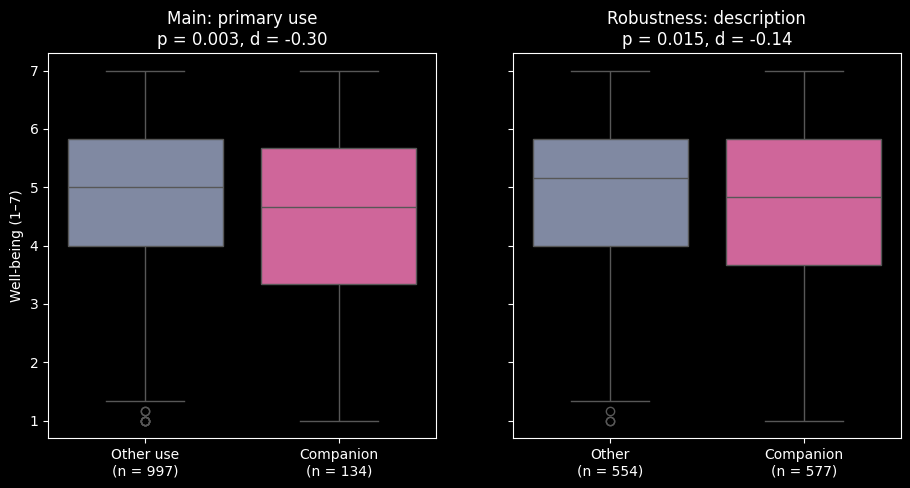

In [88]:
plt.style.use("dark_background")
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

colors = {0: "#7A86A8", 1: "#E0559A"}
p      = stats.ttest_ind(companion, others, equal_var=False).pvalue
p_desc = stats.ttest_ind(companion_desc, other_desc, equal_var=False).pvalue

# левый график: основное определение (prim)
sns.boxplot(data=df, x="companionship_prim", y="well_being",
            hue="companionship_prim", palette=colors, legend=False, ax=axes[0])
axes[0].set_xticks([0, 1], ["Other use\n(n = 997)", "Companion\n(n = 134)"])
axes[0].set_title(f"Main: primary use\np = {p:.3f}, d = {d:.2f}")
axes[0].set_xlabel("")
axes[0].set_ylabel("Well-being (1–7)")

# правый график: широкое определение (desc)
sns.boxplot(data=df, x="companionship_desc", y="well_being",
            hue="companionship_desc", palette=colors, legend=False, ax=axes[1])
axes[1].set_xticks([0, 1], ["Other\n(n = 554)", "Companion\n(n = 577)"])
axes[1].set_title(f"Robustness: description\np = {p_desc:.3f}, d = {d_desc:.2f}")
axes[1].set_xlabel("")

plt.savefig("rq1_robustness.png", dpi=200, bbox_inches="tight", transparent=True)
plt.show()